In [41]:
print("Customer Segmentation Project Started")

Customer Segmentation Project Started


# Customer Segmentation using RFM Analysis

## Project Overview

This project applies RFM Analysis to segment customers based on purchasing behavior and generate actionable business insights.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [44]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [45]:
df.shape

(541909, 8)

## Data Cleaning

The dataset was cleaned to ensure accurate customer segmentation. Missing Customer IDs, cancelled transactions, negative quantities, and invalid pricing records were removed. This process improved data quality and ensured reliable analytical results.



In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [47]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [48]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [49]:
df.duplicated().sum()

np.int64(5268)

In [50]:
df = df.dropna(subset=['CustomerID'])

In [51]:
df.shape

(406829, 8)

In [52]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [53]:
df.shape

(397924, 8)

In [54]:
df = df[df['Quantity'] > 0]

In [55]:
df.shape

(397924, 8)

### Cleaning Summary

- Original Dataset Shape: 541,909 rows × 8 columns
- Final Dataset Shape: 397,924 rows × 8 columns
- Removed records with missing Customer IDs
- Excluded cancelled transactions
- Removed negative quantities
- Filtered invalid pricing values

## Feature Engineering

A new metric called TotalAmount is created by multiplying Quantity and UnitPrice. This metric represents the revenue generated from each transaction.

In [56]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [57]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [58]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='str')

In [59]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [60]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalAmount           float64
dtype: object

## RFM Analysis

RFM Analysis is used to evaluate customer behavior based on three key metrics:

- Recency: How recently a customer made a purchase.
- Frequency: How often a customer makes purchases.
- Monetary: How much money a customer has spent.

These metrics help identify valuable customers and support strategic business decisions.

In [61]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [62]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [63]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [64]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [65]:
rfm.shape

(4339, 3)

## RFM Scoring

Customers are scored based on their Recency, Frequency, and Monetary values. Higher scores indicate more valuable and engaged customers.

In [66]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [67]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [68]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [69]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [70]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


### Interpretation of RFM Scores

- Higher Recency scores indicate more recent purchases.
- Higher Frequency scores indicate more frequent purchases.
- Higher Monetary scores indicate higher spending.
- Customers with high scores across all three dimensions are considered the most valuable customers.

## Customer Segmentation

Customers are categorized into different segments based on their RFM characteristics. These segments help businesses design targeted marketing and retention strategies.

In [71]:
def segment_customer(row):

    if row['Recency'] <= 30 and row['Frequency'] >= 10:
        return 'High Value'

    elif row['Recency'] <= 60:
        return 'Loyal'

    elif row['Frequency'] <= 2:
        return 'New Customer'

    elif row['Recency'] > 180:
        return 'At Risk'

    else:
        return 'Regular'

In [72]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [73]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,New Customer
12347.0,2,7,4310.00,4,4,4,444,Loyal
12348.0,75,4,1797.24,2,3,4,234,Regular
12349.0,19,1,1757.55,3,1,4,314,Loyal
12350.0,310,1,334.40,1,1,2,112,New Customer


In [74]:
rfm['Segment'].value_counts()

Segment
Loyal           2051
New Customer    1474
Regular          383
High Value       346
At Risk           85
Name: count, dtype: int64

## Customer Segment Distribution

The following visualization shows the distribution of customers across different segments identified through RFM Analysis.

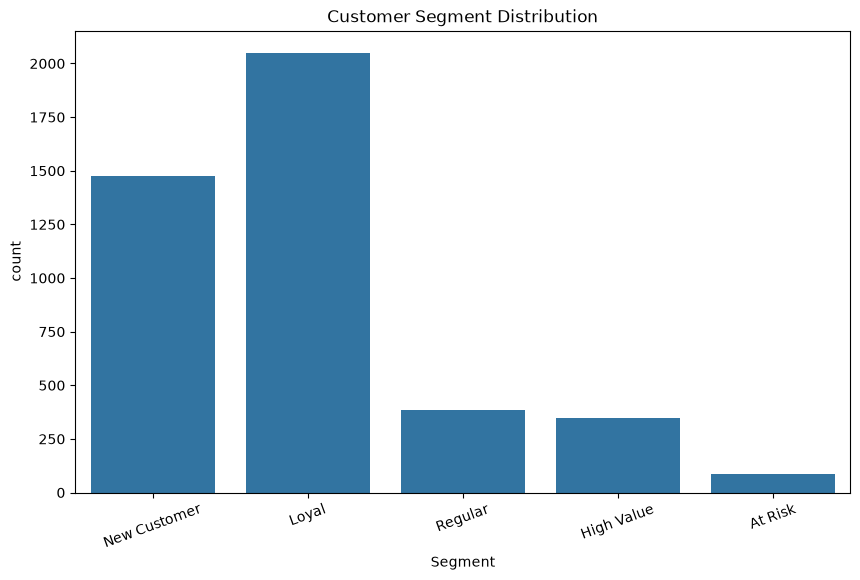

In [75]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.title('Customer Segment Distribution')
plt.xticks(rotation=20)

plt.show()

## Revenue Contribution by Segment

This chart illustrates the total revenue generated by each customer segment.

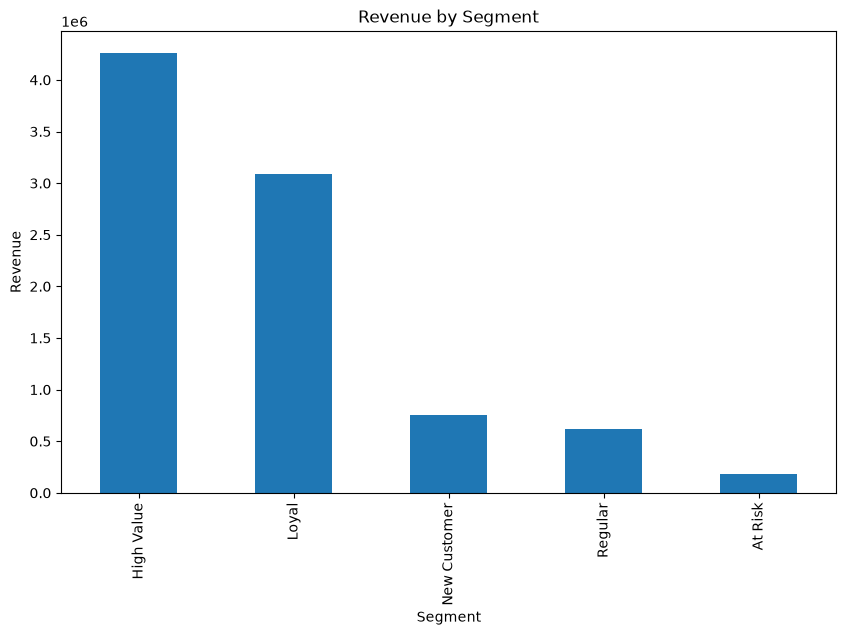

In [76]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Revenue by Segment')
plt.ylabel('Revenue')

plt.show()

## Segment Performance Summary

Average customer behavior metrics for each segment are analyzed to support business decision-making.

In [77]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

segment_summary.round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,231.48,4.27,2110.54
High Value,9.51,20.26,12318.05
Loyal,25.46,3.68,1508.13
New Customer,195.12,1.29,511.97
Regular,100.93,4.49,1624.45


## Business Insights

The RFM analysis revealed distinct customer segments with varying purchasing behaviors and revenue contributions.

### High Value Customers

* Highest average spending (£12,318.05) and purchase frequency (20.26).
* Most engaged and profitable customer segment.
* Should be targeted through VIP programs, exclusive offers, and loyalty rewards.

### Loyal Customers

* Largest customer segment with consistent purchasing behavior.
* Strong potential to be converted into high-value customers.
* Personalized recommendations and retention campaigns can improve long-term value.

### New Customers

* Low purchase frequency and spending levels.
* Represent future growth opportunities.
* Welcome campaigns and onboarding offers can encourage repeat purchases.

### Regular Customers

* Moderate spending and purchase frequency.
* Can be nurtured through cross-selling and promotional campaigns.

### At Risk Customers

* Highest average recency value, indicating long periods without purchases.
* Require re-engagement campaigns, personalized offers, and retention strategies.

Overall, the analysis demonstrates how customer segmentation can support targeted marketing, improve customer retention, and enhance revenue generation.


## Conclusion

This project successfully applied RFM Analysis to segment customers based on purchasing behavior using transaction-level retail data.

The analysis identified 4,339 unique customers and classified them into meaningful business segments including High Value, Loyal, New, Regular, and At Risk customers.

The results highlight the importance of customer analytics in understanding customer value, improving retention strategies, and supporting data-driven decision-making. By leveraging RFM Analysis, businesses can design personalized marketing campaigns, allocate resources effectively, and maximize customer lifetime value.

This project demonstrates practical applications of Python, data cleaning, feature engineering, customer analytics, and business intelligence in solving real-world business problems.


In [78]:
rfm.to_csv("customer_segments.csv")